# MobileNetV1 — Depthwise Separable Convolutions

## Overview

This notebook implements MobileNetV1 from first principles in PyTorch. The central architectural idea is factorizing standard convolutions into depthwise spatial filtering and pointwise channel mixing. The implementation uses Imagenette with 10 ImageNet-derived classes, and the notebook demonstrates the data pipeline, model construction, inspection, training, evaluation, and prediction workflow.


## Table of Contents

- [Overview](#overview)
- [Learning Objectives](#learning-objectives)
- [Architecture Theory](#architecture-theory)
- [Environment Setup](#environment-setup)
- [Configuration](#configuration)
- [Reproducibility](#reproducibility)
- [Device Selection](#device-selection)
- [Dataset Download](#dataset-download)
- [Data Augmentation and Preprocessing](#data-augmentation-and-preprocessing)
- [Dataset Construction and Splitting](#dataset-construction-and-splitting)
- [Data Loaders](#data-loaders)
- [Dataset Inspection](#dataset-inspection)
- [Architecture Components](#architecture-components)
- [Complete Model](#complete-model)
- [Model Initialization](#model-initialization)
- [Model Inspection](#model-inspection)
- [Training Objective](#training-objective)
- [Optimizer](#optimizer)
- [Learning Rate Scheduler](#learning-rate-scheduler)
- [Training Loop](#training-loop)
- [Test Evaluation](#test-evaluation)
- [Prediction Visualization](#prediction-visualization)
- [Key Takeaways](#key-takeaways)


## Learning Objectives

By the end of this notebook, we should understand:

- how depthwise convolution differs from standard convolution.
- why pointwise `1 x 1` convolution is needed after depthwise filtering.
- how depthwise separable convolution reduces computation.
- how the width multiplier controls channel capacity in this implementation.
- how MobileNetV1 is trained and evaluated on Imagenette.


## Architecture Theory

A standard convolution jointly performs spatial filtering and channel mixing. For kernel size `D_K`, input channels `M`, output channels `N`, and feature-map width/height `D_F`, its approximate cost is

$$
D_K^2 M N D_F^2.
$$

MobileNetV1 factorizes this operation. A depthwise convolution applies one spatial filter per input channel, and a pointwise `1 x 1` convolution mixes channels afterward. The approximate cost becomes

$$
D_K^2 M D_F^2 + M N D_F^2.
$$

This reduces computation because the expensive spatial kernel is no longer repeated for every output channel. The implementation also includes a width multiplier, which scales channel counts to trade accuracy for efficiency.


## Environment Setup

The notebook uses PyTorch for tensor computation and neural network modules, torchvision for datasets and transforms, NumPy and Python randomness for reproducibility, and Matplotlib for visualization.


In [1]:
from __future__ import annotations

import copy
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.datasets.utils import download_and_extract_archive


## Configuration

The following constants define the experiment. They are kept from the source script so the notebook remains traceable to the original implementation.


In [2]:
DATA_DIRECTORY = "./data"

IMAGENETTE_URL = (
    "https://s3.amazonaws.com/"
    "fast-ai-imageclas/"
    "imagenette2-320.tgz"
)

IMAGENETTE_FOLDER = "imagenette2-320"

IMAGE_SIZE = 224
BATCH_SIZE = 32

LEARNING_RATE = 0.01
NUMBER_OF_EPOCHS = 30

VALIDATION_RATIO = 0.1
RANDOM_SEED = 42
NUMBER_OF_WORKERS = 0

NUMBER_OF_CLASSES = 10
WIDTH_MULTIPLIER = 1.0

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


## Reproducibility

Random seeds make dataset splitting, parameter initialization, and stochastic operations easier to reproduce across runs. Exact determinism can still depend on hardware kernels and backend behavior.


In [3]:
def set_seed(seed: int = RANDOM_SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()


## Device Selection

The model is moved to the best available device. CUDA is preferred when available, followed by Apple MPS, and then CPU.


In [4]:
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")

    if torch.backends.mps.is_available():
        return torch.device("mps")

    return torch.device("cpu")


device = get_device()

print(f"Using device: {device}")


Using device: cuda


## Dataset Download

Imagenette is a ten-class subset of ImageNet. The helper below downloads and prepares the archive if it is not already present.


In [5]:
def prepare_imagenette(
    data_directory: str = DATA_DIRECTORY,
) -> Path:

    root_directory = Path(data_directory)
    dataset_directory = root_directory / IMAGENETTE_FOLDER

    training_directory = dataset_directory / "train"
    validation_directory = dataset_directory / "val"

    if training_directory.exists() and validation_directory.exists():
        print(f"Imagenette already exists in {dataset_directory}.")
        return dataset_directory

    root_directory.mkdir(parents=True, exist_ok=True)

    print("Downloading and extracting Imagenette...")

    download_and_extract_archive(
        url=IMAGENETTE_URL,
        download_root=str(root_directory),
        extract_root=str(root_directory),
    )

    return dataset_directory


imagenette_directory = prepare_imagenette()


100%|██████████| 342M/342M [00:21<00:00, 15.8MB/s]


## Data Augmentation and Preprocessing

Training transforms are stochastic and regularize the model through random crops or flips. Evaluation transforms are deterministic so validation and test metrics are comparable across runs. Normalization maps image channels into the scale expected by the training recipe.


In [6]:
training_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        size=IMAGE_SIZE,
        scale=(0.8, 1.0),
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])


evaluation_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])


## Dataset Construction and Splitting

The dataset objects define the supervised image-classification task and its train, validation, and test usage. The source implementation creates validation data from the training split and reserves the official evaluation split for final testing where applicable.


In [7]:
training_directory = imagenette_directory / "train"
test_directory = imagenette_directory / "val"


training_dataset_full = datasets.ImageFolder(
    root=training_directory,
    transform=training_transform,
)

validation_dataset_full = datasets.ImageFolder(
    root=training_directory,
    transform=evaluation_transform,
)

test_dataset = datasets.ImageFolder(
    root=test_directory,
    transform=evaluation_transform,
)


number_of_samples = len(training_dataset_full)

number_of_validation_samples = int(
    VALIDATION_RATIO * number_of_samples
)


generator = torch.Generator().manual_seed(RANDOM_SEED)

indices = torch.randperm(
    number_of_samples,
    generator=generator,
).tolist()


validation_indices = indices[:number_of_validation_samples]

training_indices = indices[number_of_validation_samples:]


training_dataset = Subset(
    training_dataset_full,
    training_indices,
)

validation_dataset = Subset(
    validation_dataset_full,
    validation_indices,
)


print(f"Training samples:   {len(training_dataset):,}")
print(f"Validation samples: {len(validation_dataset):,}")
print(f"Test samples:       {len(test_dataset):,}")
print(f"Number of classes:  {len(training_dataset_full.classes)}")


Training samples:   8,523
Validation samples: 946
Test samples:       3,925
Number of classes:  10


## Data Loaders

Data loaders batch examples, optionally shuffle the training subset, and pin memory when CUDA is used. Validation and test loaders are not shuffled because their order does not affect the metrics.


In [8]:
pin_memory = device.type == "cuda"


training_loader = DataLoader(
    dataset=training_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUMBER_OF_WORKERS,
    pin_memory=pin_memory,
)

validation_loader = DataLoader(
    dataset=validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUMBER_OF_WORKERS,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUMBER_OF_WORKERS,
    pin_memory=pin_memory,
)


## Dataset Inspection

A small batch visualization helps verify that augmentation, normalization, and labels are wired correctly. The display reverses normalization before plotting.


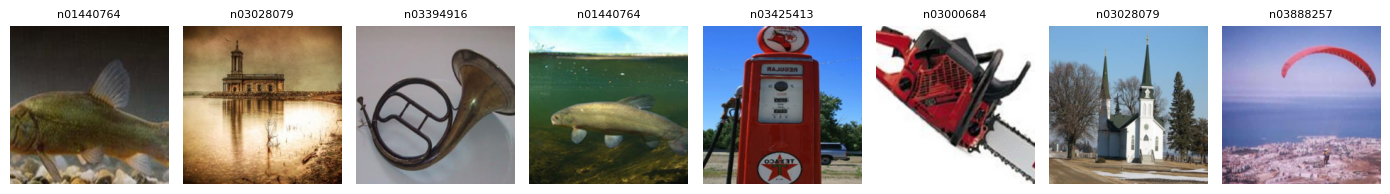

In [9]:
def show_training_examples(data_loader: DataLoader, number_of_images: int = 8) -> None:
    images, labels = next(iter(data_loader))
    images = images[:number_of_images]
    labels = labels[:number_of_images]

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    images = (images.cpu() * std + mean).clamp(0, 1)

    class_names = training_dataset_full.classes
    fig, axes = plt.subplots(1, number_of_images, figsize=(14, 2.5))

    for axis, image, label in zip(axes, images, labels):
        axis.imshow(image.permute(1, 2, 0))
        axis.set_title(class_names[int(label)], fontsize=8)
        axis.axis("off")

    plt.tight_layout()
    plt.show()

show_training_examples(training_loader)


## Architecture Components

### Depthwise Separable Block

The block below implements MobileNetV1 factorization: depthwise convolution performs spatial filtering independently per channel, and pointwise convolution mixes information across channels.


In [10]:
class DepthwiseSeparableBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1) -> None:
        super().__init__()

        # ----------------------------------------------------
        # Depthwise 3x3 Convolution
        # ----------------------------------------------------
        self.depthwise = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=in_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                groups=in_channels,
                bias=False
            ),
            nn.BatchNorm2d(num_features=in_channels),
            nn.ReLU(inplace=True)
        )

        # ----------------------------------------------------
        # Pointwise 1x1 Convolution
        # ----------------------------------------------------
        self.pointwise = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False
            ),
            nn.BatchNorm2d(num_features=out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x


## Complete Model

### Complete MobileNetV1 Model

The full network begins with a standard convolution and then repeatedly applies depthwise separable blocks. Spatial resolution decreases at selected stages while channel capacity increases.


In [11]:
class MobileNetV1(nn.Module):
    def __init__(self, number_of_classes: int = NUMBER_OF_CLASSES, width_multiplier: float = WIDTH_MULTIPLIER) -> None:
        super().__init__()

        self.width_multiplier = width_multiplier

        channels = lambda value: max(1, int(value * self.width_multiplier))

        c32 = channels(32)
        c64 = channels(64)
        c128 = channels(128)
        c256 = channels(256)
        c512 = channels(512)
        c1024 = channels(1024)

        # ====================================================
        # STEM
        # ====================================================
        self.stem = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=c32,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(inplace=True)
        )

        # ====================================================
        # DEPTHWISE SEPARABLE BLOCKS
        # ====================================================
        self.block1 = DepthwiseSeparableBlock(in_channels=c32, out_channels=c64, stride=1)
        self.block2 = DepthwiseSeparableBlock(in_channels=c64, out_channels=c128, stride=2)
        self.block3 = DepthwiseSeparableBlock(in_channels=c128, out_channels=c128, stride=1)
        self.block4 = DepthwiseSeparableBlock(in_channels=c128, out_channels=c256, stride=2)
        self.block5 = DepthwiseSeparableBlock(in_channels=c256, out_channels=c256, stride=1)
        self.block6 = DepthwiseSeparableBlock(in_channels=c256, out_channels=c512, stride=2)
        self.block7 = DepthwiseSeparableBlock(in_channels=c512, out_channels=c512, stride=1)
        self.block8 = DepthwiseSeparableBlock(in_channels=c512, out_channels=c512, stride=1)
        self.block9 = DepthwiseSeparableBlock(in_channels=c512, out_channels=c512, stride=1)
        self.block10 = DepthwiseSeparableBlock(in_channels=c512, out_channels=c512, stride=1)
        self.block11 = DepthwiseSeparableBlock(in_channels=c512, out_channels=c512, stride=1)
        self.block12 = DepthwiseSeparableBlock(in_channels=c512, out_channels=c1024, stride=2)
        self.block13 = DepthwiseSeparableBlock(in_channels=c1024, out_channels=c1024, stride=1)

        # ====================================================
        # CLASSIFIER
        # ====================================================
        self.classifier = nn.Sequential(
            nn.AvgPool2d(kernel_size=7, stride=1),
            nn.Flatten(start_dim=1),
            nn.Linear(in_features=c1024, out_features=number_of_classes)
        )

        self._initialize_weights()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.block7(x)
        x = self.block8(x)
        x = self.block9(x)
        x = self.block10(x)
        x = self.block11(x)
        x = self.block12(x)
        x = self.block13(x)
        logits = self.classifier(x)

        return logits

    def _initialize_weights(self) -> None:
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")

            elif isinstance(module, nn.BatchNorm2d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

            elif isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, 0, 0.01)
                nn.init.zeros_(module.bias)

    # ========================================================
    # PARAMETER COUNT
    # ========================================================
    def count_parameters(self) -> tuple[int, int]:

        total_parameters = sum(
            parameter.numel()
            for parameter in self.parameters()
        )

        trainable_parameters = sum(
            parameter.numel()
            for parameter in self.parameters()
            if parameter.requires_grad
        )

        return total_parameters, trainable_parameters

    # ========================================================
    # TRAIN ONE EPOCH
    # ========================================================
    def _train_one_epoch(
        self,
        data_loader: DataLoader,
        loss_function: nn.Module,
        optimizer: torch.optim.Optimizer,
        device: torch.device,
    ) -> tuple[float, float]:

        self.train()

        accumulated_loss = 0.0

        number_of_correct_predictions = 0
        number_of_samples = 0

        for images, labels in data_loader:
            images = images.to(device, non_blocking=(device.type == "cuda"))
            labels = labels.to(device, non_blocking=(device.type == "cuda"))

            optimizer.zero_grad(set_to_none=True)

            logits = self(images)

            loss = loss_function(logits, labels)

            loss.backward()

            optimizer.step()

            accumulated_loss += loss.item() * images.size(0)

            predictions = torch.argmax(logits, dim=1)

            number_of_correct_predictions += (predictions == labels).sum().item()

            number_of_samples += images.size(0)

        average_loss = accumulated_loss / number_of_samples
        average_accuracy = number_of_correct_predictions / number_of_samples

        return average_loss, average_accuracy

    # ========================================================
    # EVALUATE
    # ========================================================
    def evaluate(
        self,
        data_loader: DataLoader,
        loss_function: nn.Module,
        device: torch.device
    ) -> tuple[float, float]:

        self.eval()

        accumulated_loss = 0.0

        number_of_correct_predictions = 0
        number_of_samples = 0

        with torch.inference_mode():
            for images, labels in data_loader:
                images = images.to(device, non_blocking=(device.type == "cuda"))
                labels = labels.to(device, non_blocking=(device.type == "cuda"))

                logits = self(images)

                loss = loss_function(logits, labels)

                accumulated_loss += loss.item() * images.size(0)

                predictions = torch.argmax(logits, dim=1)

                number_of_correct_predictions += (predictions == labels).sum().item()

                number_of_samples += images.size(0)

        average_loss = accumulated_loss / number_of_samples
        average_accuracy = number_of_correct_predictions / number_of_samples

        return average_loss, average_accuracy

    # ========================================================
    # FIT
    # ========================================================
    def fit(
        self,
        training_loader: DataLoader,
        validation_loader: DataLoader,
        loss_function: nn.Module,
        optimizer: torch.optim.Optimizer,
        number_of_epochs: int,
        device: torch.device,
        scheduler=None,
        restore_best_weights: bool = True
    ) -> dict[str, list[float]]:

        self.to(device)

        history = {
            "training_loss": [],
            "training_accuracy": [],
            "validation_loss": [],
            "validation_accuracy": []
        }

        best_validation_accuracy = float("-inf")
        best_state_dict = None

        for epoch in range(1, number_of_epochs + 1):

            training_loss, training_accuracy = self._train_one_epoch(
                data_loader=training_loader,
                loss_function=loss_function,
                optimizer=optimizer,
                device=device
            )

            validation_loss, validation_accuracy = self.evaluate(
                data_loader=validation_loader,
                loss_function=loss_function,
                device=device
            )

            history["training_loss"].append(training_loss)
            history["training_accuracy"].append(training_accuracy)
            history["validation_loss"].append(validation_loss)
            history["validation_accuracy"].append(validation_accuracy)

            if validation_accuracy > best_validation_accuracy:
                best_validation_accuracy = validation_accuracy
                best_state_dict = copy.deepcopy(self.state_dict())

            current_learning_rate = optimizer.param_groups[0]["lr"]

            print(
                f"Epoch [{epoch:02d}/{number_of_epochs:02d}] | "
                f"LR: {current_learning_rate:.6f} | "
                f"Train loss: {training_loss:.4f} | "
                f"Train accuracy: {training_accuracy:.2%} | "
                f"Validation loss: {validation_loss:.4f} | "
                f"Validation accuracy: {validation_accuracy:.2%}"
            )

            if scheduler is not None:
                scheduler.step()

        if restore_best_weights and best_state_dict is not None:
            self.load_state_dict(best_state_dict)

        return history

    # ========================================================
    # PREDICT
    # ========================================================
    def predict(
        self,
        data_loader: DataLoader,
        device: torch.device
    ) -> tuple[torch.Tensor, torch.Tensor]:

        self.eval()

        all_predictions = []
        all_labels = []

        with torch.inference_mode():
            for images, labels in data_loader:
                images = images.to(device, non_blocking=(device.type == "cuda"))

                logits = self(images)

                predictions = torch.argmax(logits, dim=1)

                all_predictions.append(predictions.cpu())
                all_labels.append(labels)

        predictions = torch.cat(all_predictions, dim=0)
        labels = torch.cat(all_labels, dim=0)

        return predictions, labels


## Model Initialization

The model is instantiated with the configured number of classes and moved to the selected device so parameters and input tensors live on the same backend.


In [12]:
model = MobileNetV1(
    number_of_classes=NUMBER_OF_CLASSES,
    width_multiplier=WIDTH_MULTIPLIER,
).to(device)


total_parameters, trainable_parameters = (
    model.count_parameters()
)


print(f"\nTotal parameters:     {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")



Total parameters:     3,217,226
Trainable parameters: 3,217,226


## Model Inspection

Shape inspection is a lightweight sanity check. It verifies that a synthetic input flows through the model and produces logits with the expected class dimension.


In [13]:
def inspect_model_shapes(
    model: MobileNetV1,
    device: torch.device,
) -> None:

    x = torch.randn(
        2,
        3,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=device,
    )


    model.eval()


    with torch.inference_mode():

        print("\nShape inspection:")

        print(f"Input:     {tuple(x.shape)}")


        x = model.stem(x)
        print(f"Stem:      {tuple(x.shape)}")


        x = model.block1(x)
        print(f"Block 1:   {tuple(x.shape)}")


        x = model.block2(x)
        print(f"Block 2:   {tuple(x.shape)}")


        x = model.block3(x)
        print(f"Block 3:   {tuple(x.shape)}")


        x = model.block4(x)
        print(f"Block 4:   {tuple(x.shape)}")


        x = model.block5(x)
        print(f"Block 5:   {tuple(x.shape)}")


        x = model.block6(x)
        print(f"Block 6:   {tuple(x.shape)}")


        x = model.block7(x)
        x = model.block8(x)
        x = model.block9(x)
        x = model.block10(x)
        x = model.block11(x)

        print(f"Block 11:  {tuple(x.shape)}")


        x = model.block12(x)
        print(f"Block 12:  {tuple(x.shape)}")


        x = model.block13(x)
        print(f"Block 13:  {tuple(x.shape)}")


        logits = model.classifier(x)
        print(f"Logits:    {tuple(logits.shape)}")


inspect_model_shapes(
    model=model,
    device=device,
)



Shape inspection:
Input:     (2, 3, 224, 224)
Stem:      (2, 32, 112, 112)
Block 1:   (2, 64, 112, 112)
Block 2:   (2, 128, 56, 56)
Block 3:   (2, 128, 56, 56)
Block 4:   (2, 256, 28, 28)
Block 5:   (2, 256, 28, 28)
Block 6:   (2, 512, 14, 14)
Block 11:  (2, 512, 14, 14)
Block 12:  (2, 1024, 7, 7)
Block 13:  (2, 1024, 7, 7)
Logits:    (2, 10)


## Training Objective

For multi-class image classification, the network produces unnormalized logits. `CrossEntropyLoss` combines log-softmax with negative log-likelihood.


In [14]:
loss_function = nn.CrossEntropyLoss()


## Optimizer

The optimizer defines how gradients update model parameters. The learning rate is kept exactly as configured in the source implementation.


In [15]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE,
    momentum=0.9,
    weight_decay=1e-4,
)


## Learning Rate Scheduler

The scheduler changes the learning rate during training according to the source implementation. This can improve convergence without changing the model architecture.


In [16]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1,
)


## Training Loop

The training loop coordinates epochs, validation, history recording, and scheduler updates. Running the next cell can take a long time because it executes the full configured experiment.


In [17]:
history = model.fit(
    training_loader=training_loader,
    validation_loader=validation_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    number_of_epochs=NUMBER_OF_EPOCHS,
    device=device,
    scheduler=scheduler,
    restore_best_weights=True,
)


Epoch [01/30] | LR: 0.010000 | Train loss: 2.0008 | Train accuracy: 28.36% | Validation loss: 2.2758 | Validation accuracy: 39.01%
Epoch [02/30] | LR: 0.010000 | Train loss: 1.5478 | Train accuracy: 49.67% | Validation loss: 1.4790 | Validation accuracy: 50.85%
Epoch [03/30] | LR: 0.010000 | Train loss: 1.2832 | Train accuracy: 58.34% | Validation loss: 1.3425 | Validation accuracy: 60.15%
Epoch [04/30] | LR: 0.010000 | Train loss: 1.1133 | Train accuracy: 63.75% | Validation loss: 1.0269 | Validation accuracy: 65.75%
Epoch [05/30] | LR: 0.010000 | Train loss: 1.0055 | Train accuracy: 67.48% | Validation loss: 1.0682 | Validation accuracy: 65.22%
Epoch [06/30] | LR: 0.010000 | Train loss: 0.8913 | Train accuracy: 71.16% | Validation loss: 0.9546 | Validation accuracy: 68.39%
Epoch [07/30] | LR: 0.010000 | Train loss: 0.8159 | Train accuracy: 73.46% | Validation loss: 1.0487 | Validation accuracy: 65.64%
Epoch [08/30] | LR: 0.010000 | Train loss: 0.7536 | Train accuracy: 75.42% | Valida

## Test Evaluation

The test set is used after training for final evaluation. Training data optimizes parameters, validation data monitors model selection, and test data estimates final generalization.


In [18]:
test_loss, test_accuracy = model.evaluate(
    data_loader=test_loader,
    loss_function=loss_function,
    device=device,
)


print("\nTest results:")
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")



Test results:
Test loss:     0.6694
Test accuracy: 79.52%


## Prediction Visualization

Prediction visualization connects logits back to input images, ground-truth labels, and predicted labels. Images are denormalized before display when needed.


In [19]:
predictions, labels = model.predict(
    data_loader=test_loader,
    device=device,
)


print(f"\nPrediction tensor shape: {predictions.shape}")
print(f"Label tensor shape:      {labels.shape}")



Prediction tensor shape: torch.Size([3925])
Label tensor shape:      torch.Size([3925])


## Key Takeaways

- MobileNetV1 separates spatial filtering from channel mixing.
- Depthwise separable convolution greatly reduces multiply-add cost relative to standard convolution.
- The width multiplier changes model capacity without changing the basic architecture pattern.
